# Notebook 07 - Experimento 3: Adaptación al dominio objetivo (LECA1)

## Pregunta que responde
¿Cuánto mejora el rendimiento del modelo cuando se incorporan datos reales
de la planta objetivo (LECA1) al conjunto de entrenamiento?

## Diseño experimental

| Escenario | Train | Test |
|---|---|---|
| Base (notebook 03) | Afrisol + E03, 2022-2023 | LECA1, mar-may 2024 |
| Adaptado (este notebook) | Afrisol + E03 + LECA1 mar-abr 2024 | LECA1, may 2024 |

## Motivación
En un despliegue real, tras instalar el sistema en una nueva planta, normalmente
se dispone de algunos meses de histórico local antes de necesitar predicciones
fiables. Este experimento cuantifica el valor de ese histórico local.

## Puntos metodológicos clave
- `one_hot_encode_plant=False`: la mejora se debe exclusivamente a los datos
  locales, no a la identidad de la planta.
- El conjunto de validación sigue siendo Afrisol + E03 para mantener
  coherencia con el modelo global.
- La comparación se realiza sobre horas de producción (daylight) para
  evitar el sesgo de los períodos nocturnos.


### 1. Configuración de rutas e importaciones


In [1]:
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
MODELS_DIR  = DATA_DIR / "models"
RESULTS_DIR = DATA_DIR / "results"

from src.data import add_nominal_power_and_target
from src.evaluation import (
    compute_metrics,
    evaluate_all_models_daylight,
    train_and_evaluate_models,
)
from src.features import FeatureConfig, build_features, get_feature_columns
from src.models import get_baseline_models

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga y preparación de datos


In [2]:
df_all = pd.read_csv(DATA_DIR / "df_all_unificado.csv", parse_dates=["timestamp"])

NOMINAL_POWER = {"E03": 12.4, "Afrisol": 12.0, "LECA1": 19.53}
df_all = df_all.drop(columns=["power_pu", "p_nominal_kw"], errors="ignore")
df_all = add_nominal_power_and_target(df_all, NOMINAL_POWER)

avail = df_all.groupby("id_planta").agg(
    min=("timestamp", "min"),
    max=("timestamp", "max"),
    count=("timestamp", "count"),
)
avail["meses"] = (avail["max"] - avail["min"]).dt.days / 30
print("Datos disponibles por planta:")
display(avail.round(1))


Datos disponibles por planta:


,min,max,count,meses
id_planta,,,,
Afrisol,2022-01-01,2024-04-29 23:45:00,81111,28.3
E03,2022-01-01,2024-05-30 23:45:00,84087,29.3
LECA1,2022-01-01,2024-05-30 23:45:00,84087,29.3


### 3. Ingeniería de variables (configuracion con lag)


In [3]:
config = FeatureConfig(
    lag_steps_power=(1, 2, 4),
    lag_steps_radiation=(1, 2),
    rolling_windows_power=(4, 8),
    rolling_windows_radiation=(4,),
    add_interactions=True,
    add_daylight_flag=True,
    drop_na_after_features=True,
    one_hot_encode_plant=False,
)

df_feat = build_features(df_all, config=config)
df_feat = df_feat.drop(columns=["Mes"], errors="ignore")

print(f"Dataset con features: {df_feat.shape}")
display(df_feat.groupby("id_planta")["timestamp"].agg(["min", "max", "count"]))


Dataset con features: (249273, 37)


,min,max,count
id_planta,,,
Afrisol,2022-01-01 01:00:00,2024-04-29 23:45:00,81107
E03,2022-01-01 01:00:00,2024-05-30 23:45:00,84083
LECA1,2022-01-01 01:00:00,2024-05-30 23:45:00,84083


### 4. Partición adaptada
Se añaden los datos de LECA1 de marzo-abril 2024 al conjunto de *train*.
El *test* se restringe a mayo 2024 (datos nunca vistos durante el entrenamiento).


In [4]:
# Train base: Afrisol + E03 hasta fin de 2023
df_base_train = df_feat[
    df_feat["id_planta"].isin(["Afrisol", "E03"]) &
    (df_feat["timestamp"] < "2023-12-31")
]

# Train LECA1: marzo-abril 2024 (dos meses de historico local)
df_leca1_train = df_feat[
    (df_feat["id_planta"] == "LECA1") &
    (df_feat["timestamp"] >= "2024-03-01") &
    (df_feat["timestamp"] < "2024-04-30")
]

# Validacion: Afrisol + E03, enero-febrero 2024
df_val = df_feat[
    df_feat["id_planta"].isin(["Afrisol", "E03"]) &
    (df_feat["timestamp"] >= "2024-01-01") &
    (df_feat["timestamp"] < "2024-02-29")
]

# Test: LECA1 mayo 2024 (no visto en ningun momento)
df_test = df_feat[
    (df_feat["id_planta"] == "LECA1") &
    (df_feat["timestamp"] >= "2024-05-01") &
    (df_feat["timestamp"] < "2024-05-30")
]

df_train = pd.concat([df_base_train, df_leca1_train], ignore_index=True)

print(f"Train base (E03 + Afrisol): {len(df_base_train):>8,} filas")
print(f"LECA1 train (mar-abr 2024): {len(df_leca1_train):>8,} filas")
print(f"Train total:                {len(df_train):>8,} filas")
print(f"Validacion:                 {len(df_val):>8,} filas")
print(f"Test (LECA1 mayo 2024):     {len(df_test):>8,} filas")

feature_cols = get_feature_columns(df_train)

TARGET = "power_pu"
X_train, y_train = df_train[feature_cols], df_train[TARGET]
X_val,   y_val   = df_val[feature_cols],   df_val[TARGET]
X_test,  y_test  = df_test[feature_cols],  df_test[TARGET]

print(f"\nFeatures: {len(feature_cols)}")
print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Train base (E03 + Afrisol):  138,984 filas
LECA1 train (mar-abr 2024):    5,760 filas
Train total:                 144,744 filas
Validacion:                   11,328 filas
Test (LECA1 mayo 2024):        2,782 filas

Features: 32
Train: (144744, 32) | Val: (11328, 32) | Test: (2782, 32)


### 5. Entrenamiento y evaluación de modelos adaptados


In [5]:
models = get_baseline_models(random_state=42)

results_val, results_test, trained_adapted = train_and_evaluate_models(
    models,
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
)

results_daylight = evaluate_all_models_daylight(
    trained_adapted, X_test, y_test
)

print("Validacion:")
display(results_val.round(6))

print("\nTest — LECA1 mayo 2024:")
display(results_test.round(6))

print("\nTest — solo horas de produccion:")
display(results_daylight.round(6))


2026-05-27 11:18:35 - INFO - Entrenando: Ridge
2026-05-27 11:18:35 - INFO -   Val  -> MAE: 0.0109 | RMSE: 0.0258 | R2: 0.9795
2026-05-27 11:18:35 - INFO -   Test -> MAE: 0.0214 | RMSE: 0.0468 | R2: 0.9725
2026-05-27 11:18:35 - INFO - Entrenando: Random Forest
2026-05-27 11:23:56 - INFO -   Val  -> MAE: 0.0081 | RMSE: 0.0253 | R2: 0.9802
2026-05-27 11:23:56 - INFO -   Test -> MAE: 0.0245 | RMSE: 0.0524 | R2: 0.9655
2026-05-27 11:23:56 - INFO - Entrenando: ExtraTrees
2026-05-27 11:25:36 - INFO -   Val  -> MAE: 0.0086 | RMSE: 0.0253 | R2: 0.9803
2026-05-27 11:25:36 - INFO -   Test -> MAE: 0.0274 | RMSE: 0.0536 | R2: 0.9640
2026-05-27 11:25:36 - INFO - Entrenando: XGBoost
2026-05-27 11:25:47 - INFO -   Val  -> MAE: 0.0085 | RMSE: 0.0237 | R2: 0.9827
2026-05-27 11:25:47 - INFO -   Test -> MAE: 0.0241 | RMSE: 0.0476 | R2: 0.9716
2026-05-27 11:25:47 - INFO - Entrenando: LightGBM
2026-05-27 11:26:00 - INFO -   Val  -> MAE: 0.0087 | RMSE: 0.0235 | R2: 0.9831
2026-05-27 11:26:00 - INFO -   Test 

Validacion:


,MAE,RMSE,R2,model
0,0.008677,0.023453,0.983056,LightGBM
1,0.008466,0.023730,0.982653,XGBoost
2,0.008061,0.024784,0.981077,MLP
3,0.010296,0.025085,0.980614,CatBoost
4,0.008563,0.025281,0.980311,ExtraTrees
5,0.008089,0.025331,0.980232,Random Forest
6,0.010894,0.025803,0.979490,Ridge



Test — LECA1 mayo 2024:


,MAE,RMSE,R2,model
0,0.017691,0.041413,0.978479,MLP
1,0.021402,0.046822,0.972490,Ridge
2,0.024091,0.047581,0.971591,XGBoost
3,0.024498,0.047946,0.971153,LightGBM
4,0.025601,0.049092,0.969757,CatBoost
5,0.024495,0.052408,0.965533,Random Forest
6,0.027447,0.053591,0.963960,ExtraTrees



Test — solo horas de produccion:


,MAE,RMSE,R2,model
0,0.028803,0.053107,0.964470,MLP
1,0.031353,0.057535,0.958298,Ridge
2,0.039032,0.060566,0.953788,XGBoost
3,0.040086,0.061519,0.952322,LightGBM
4,0.041764,0.062976,0.950037,CatBoost
5,0.038878,0.065071,0.946658,Random Forest
6,0.043904,0.067491,0.942616,ExtraTrees


### 6. Comparación con el modelo base (notebook 03)
Se cuantifica la mejora en RMSE (horas de producción) al incorporar
datos locales de LECA1. Un valor positivo indica mejora respecto al
modelo entrenado sin datos de LECA1.


Impacto de anadir datos de LECA1 al entrenamiento:
(positivo = el modelo adaptado mejora respecto al base)


,model,RMSE_base,RMSE,RMSE_mejora,RMSE_mejora_%
6,ExtraTrees,0.0782,0.0675,0.0107,13.7197
3,LightGBM,0.0699,0.0615,0.0084,12.0386
2,XGBoost,0.0688,0.0606,0.0082,11.9124
4,CatBoost,0.0711,0.0630,0.0081,11.3832
0,MLP,0.0584,0.0531,0.0053,9.0808
5,Random Forest,0.0715,0.0651,0.0064,8.9633
1,Ridge,0.0586,0.0575,0.0010,1.7715


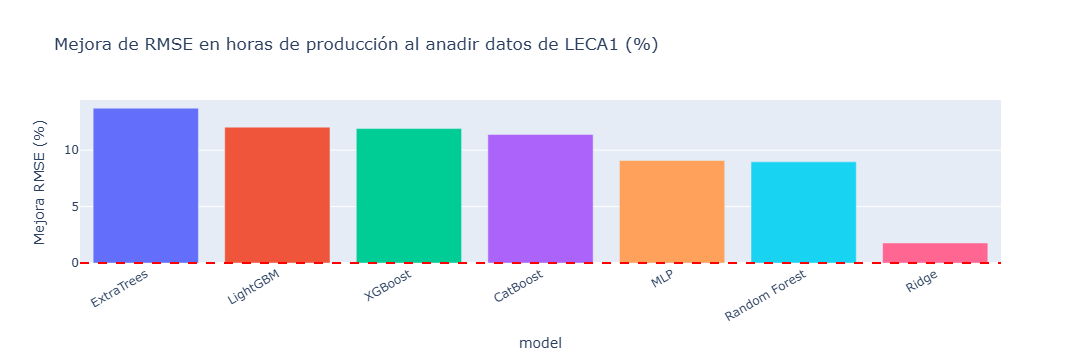

In [6]:
base_path = RESULTS_DIR / "results_test_daylight.csv"

if base_path.exists():
    df_base = pd.read_csv(base_path).rename(
        columns={"RMSE": "RMSE_base", "MAE": "MAE_base", "R2": "R2_base"}
    )
    df_comparison = results_daylight.copy().merge(
        df_base[["model", "RMSE_base"]], on="model", how="left"
    )
    df_comparison["RMSE_mejora"]    = df_comparison["RMSE_base"] - df_comparison["RMSE"]
    df_comparison["RMSE_mejora_%"]  = (
        df_comparison["RMSE_mejora"] / df_comparison["RMSE_base"] * 100
    )
    df_comparison = df_comparison.sort_values("RMSE_mejora_%", ascending=False)

    print("Impacto de anadir datos de LECA1 al entrenamiento:")
    print("(positivo = el modelo adaptado mejora respecto al base)")
    display(
        df_comparison[["model", "RMSE_base", "RMSE", "RMSE_mejora", "RMSE_mejora_%"]]
        .round(4)
    )

    fig = px.bar(
        df_comparison,
        x="model", y="RMSE_mejora_%", color="model",
        title="Mejora de RMSE en horas de producción al anadir datos de LECA1 (%)",
        labels={"RMSE_mejora_%": "Mejora RMSE (%)"},
    )
    fig.add_hline(y=0, line_dash="dash", line_color="red")
    fig.update_layout(showlegend=False, xaxis_tickangle=-30)
    fig.show()

else:
    print(
        f"Archivo base no encontrado: {base_path.name}. "
        "Ejecuta primero el notebook 03."
    )
    display(results_daylight.round(6))


### 7. Guardado de resultados y modelos


In [7]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

results_daylight.to_csv(RESULTS_DIR / "exp3_adaptado_leca1.csv", index=False)

for name, model in trained_adapted.items():
    joblib.dump(
        model,
        MODELS_DIR / f"adapted_{name.replace(' ', '_')}.joblib",
    )

print("Resultados guardados en: data/results/exp3_adaptado_leca1.csv")
print(f"Modelos adaptados guardados en: data/models/ ({len(trained_adapted)} archivos)")


Resultados guardados en: data/results/exp3_adaptado_leca1.csv
Modelos adaptados guardados en: data/models/ (7 archivos)


## Conclusiones del Experimento 3

**Hallazgos principales:**

1. Todos los modelos mejoran al incorporar datos de LECA1: el problema
   es de información local, no solo de elección del algoritmo.
2. Los modelos no lineales (árboles de decisión y *boosting*) mejoran
   más que Ridge, lo que indica que hay patrones específicos de LECA1
   que el modelo global no capturaba.
3. Ridge mejora mínimamente porque su capacidad para aprovechar
   la especificidad local es limitada.
4. La mejora es significativa con solo dos meses de datos locales,
   lo que tiene implicaciones prácticas para el despliegue real.
5. En aplicaciones reales, la disponibilidad de datos locales puede
   ser más determinante que la elección del algoritmo.

**Archivos de salida:**
- `data/results/exp3_adaptado_leca1.csv`
- `data/models/adapted_*.joblib`

**Siguiente paso:** Experimento 4 - predicción multi-horizonte.
